# Imports + Config + Reproducibility

In [1]:
import os
import sys
import time
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

EPOCHS = 50
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

def seed_worker(worker_id: int):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

if device.type == "cuda":
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print(f"Note: torch.use_deterministic_algorithms not enabled ({e}).")

Device: cuda


# Data Transform

In [2]:
try:
    aug = transforms.TrivialAugmentWide()
except AttributeError:
    aug = transforms.RandomHorizontalFlip(p=0.5)

data_transforms = {
    "train": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        aug,
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ]),
    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ]),
}

# Robust Path + Dataset + DataLoader

In [3]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "data" / "split").exists():
            return p
        if (p / "data" / "raw").exists():
            return p
    raise FileNotFoundError(
        "Project root not found (expected data/split or data/raw). "
        "Run notebook inside the project directory."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = (PROJECT_ROOT / "data" / "split").resolve()
print(f"DATA_DIR: {DATA_DIR}")

if not DATA_DIR.exists():
    raise FileNotFoundError(f"DATA_DIR tidak ditemukan: {DATA_DIR}")

phases = ["train", "val"]
for ph in phases:
    ph_dir = DATA_DIR / ph
    if not ph_dir.exists():
        raise FileNotFoundError(f"Folder subset tidak ditemukan: {ph_dir}")

image_datasets = {
    x: datasets.ImageFolder(
        root=str(DATA_DIR / x),
        transform=data_transforms[x]
    )
    for x in phases
}

train_classes = image_datasets["train"].classes
val_classes = image_datasets["val"].classes
if train_classes != val_classes:
    raise ValueError(
        "Kelas train dan val tidak identik.\n"
        f"train ({len(train_classes)}): {train_classes}\n"
        f"val   ({len(val_classes)}): {val_classes}\n"
        "Pastikan folder kelas di train/ dan val/ sama persis."
    )

class_names = train_classes
NUM_CLASSES = len(class_names)
print(f"NUM_CLASSES: {NUM_CLASSES}")

dataset_sizes = {x: len(image_datasets[x]) for x in phases}
print("Dataset sizes:", dataset_sizes)

for x in phases:
    if dataset_sizes[x] == 0:
        raise ValueError(f"Dataset '{x}' kosong. Cek folder: {DATA_DIR / x}")

train_targets = np.array(image_datasets["train"].targets)
train_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
missing_in_train = np.where(train_counts == 0)[0].tolist()
if missing_in_train:
    missing_names = [class_names[i] for i in missing_in_train]
    raise ValueError(
        f"ERROR: Ada kelas yang tidak muncul di TRAIN: {missing_names}. "
        "Training tidak valid untuk kelas ini. Periksa proses splitting."
    )

num_workers = 2
if os.name == "nt":
    num_workers = 0
if sys.platform == "darwin":
    num_workers = 0

g = torch.Generator()
g.manual_seed(SEED)

dataloaders = {
    x: DataLoader(
        image_datasets[x],
        batch_size=BATCH_SIZE,
        shuffle=(x == "train"),
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        worker_init_fn=seed_worker,
        generator=g,
        persistent_workers=(num_workers > 0),
    )
    for x in phases
}

DATA_DIR: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\data\split
NUM_CLASSES: 12
Dataset sizes: {'train': 10860, 'val': 2327}


# Class Weights

In [4]:
class_counts = train_counts.astype(np.float64)
weights = (class_counts.sum() / (NUM_CLASSES * class_counts))
weights = weights / weights.mean()

class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
print("Class weights:", class_weights.detach().cpu().numpy())

Class weights: [0.95833623 0.91939074 1.4904947  1.0151607  0.16996518 1.4396824
 1.1774354  0.8618507  1.045314   0.4577025  1.2980742  1.1665934 ]


# Model Factory

In [5]:
def _load_convnext(name: str):
    name = name.lower().strip()
    if name == "convnext_tiny":
        try:
            w = models.ConvNeXt_Tiny_Weights.DEFAULT
            return models.convnext_tiny(weights=w)
        except Exception:
            return models.convnext_tiny(pretrained=True)
    if name == "convnext_small":
        try:
            w = models.ConvNeXt_Small_Weights.DEFAULT
            return models.convnext_small(weights=w)
        except Exception:
            return models.convnext_small(pretrained=True)
    if name == "convnext_base":
        try:
            w = models.ConvNeXt_Base_Weights.DEFAULT
            return models.convnext_base(weights=w)
        except Exception:
            return models.convnext_base(pretrained=True)
    if name == "convnext_large":
        try:
            w = models.ConvNeXt_Large_Weights.DEFAULT
            return models.convnext_large(weights=w)
        except Exception:
            return models.convnext_large(pretrained=True)
    raise ValueError("Invalid model name")

def replace_last_linear(module: nn.Module, out_features: int) -> int:
    last_linear = None
    last_parent = None
    last_name = None

    for parent in module.modules():
        for name, child in parent.named_children():
            if isinstance(child, nn.Linear):
                last_linear = child
                last_parent = parent
                last_name = name

    if last_linear is None:
        raise RuntimeError("No nn.Linear layer found to replace in classifier.")

    in_features = last_linear.in_features
    setattr(last_parent, last_name, nn.Linear(in_features, out_features))
    return in_features

def get_model(name: str, num_classes: int):
    model = _load_convnext(name)

    for p in model.parameters():
        p.requires_grad = False

    if not hasattr(model, "classifier"):
        raise RuntimeError("Model does not have `.classifier` attribute as expected.")
    _ = replace_last_linear(model.classifier, num_classes)

    return model.to(device)

# Train Function

In [6]:
def atomic_torch_save(obj, path: Path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    tmp.replace(path)

def train_model(
    model,
    dataloaders,
    dataset_sizes,
    criterion,
    optimizer,
    scheduler,
    model_name: str,
    epochs: int,
    project_root: Path,
    class_names: list,
    seed: int,
    device: torch.device,
):
    project_root = Path(project_root).resolve()

    model_dir = project_root / "models" / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    report_dir = project_root / "results" / "reports" / "training" / model_name
    report_dir.mkdir(parents=True, exist_ok=True)

    run_meta = {
        "model_name": model_name,
        "seed": seed,
        "device": str(device),
        "torch_version": torch.__version__,
        "torchvision_version": getattr(models, "__version__", "unknown"),
        "num_classes": len(class_names),
        "class_names": class_names,
        "dataset_sizes": {k: int(v) for k, v in dataset_sizes.items()},
        "epochs": epochs,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
    }
    with open(report_dir / "run_metadata.json", "w") as f:
        json.dump(run_meta, f, indent=2)

    since = time.time()
    best_acc = -1.0
    best_epoch = -1
    best_weights = copy.deepcopy(model.state_dict())
    history = []

    best_ckpt_path = model_dir / "best_model.pth"

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        epoch_start = time.time()
        epoch_data = {"epoch": epoch + 1}

        for phase in ["train", "val"]:
            if dataset_sizes[phase] == 0:
                raise ValueError(f"Dataset '{phase}' kosong, tidak bisa training/eval.")

            is_train = (phase == "train")
            model.train() if is_train else model.eval()

            running_loss = 0.0
            running_correct = 0

            with torch.set_grad_enabled(is_train):
                for inputs, labels in tqdm(dataloaders[phase], desc=phase, leave=False):
                    inputs = inputs.to(device, non_blocking=(device.type == "cuda"))
                    labels = labels.to(device, non_blocking=(device.type == "cuda"))

                    if is_train:
                        optimizer.zero_grad(set_to_none=True)

                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = outputs.argmax(dim=1)

                    if is_train:
                        try:
                            loss.backward()
                            optimizer.step()
                        except RuntimeError as e:
                            if "out of memory" in str(e).lower():
                                raise RuntimeError(
                                    "CUDA OOM detected. Try lowering BATCH_SIZE, "
                                    "switching to a smaller ConvNeXt variant, "
                                    "or adding AMP/gradient accumulation."
                                ) from e
                            raise

                    running_loss += loss.item() * inputs.size(0)
                    running_correct += (preds == labels).sum().item()

            if is_train and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_correct / dataset_sizes[phase]

            print(f"{phase} | loss: {epoch_loss:.4f} | acc: {epoch_acc:.4f}")
            epoch_data[f"{phase}_loss"] = float(epoch_loss)
            epoch_data[f"{phase}_acc"] = float(epoch_acc)

            if (not is_train) and (epoch_acc > best_acc):
                best_acc = float(epoch_acc)
                best_epoch = int(epoch + 1)
                best_weights = copy.deepcopy(model.state_dict())

                ckpt = {
                    "model_state_dict": best_weights,
                    "model_name": model_name,
                    "best_val_acc": best_acc,
                    "best_epoch": best_epoch,
                    "class_names": class_names,
                    "seed": seed,
                }
                atomic_torch_save(ckpt, best_ckpt_path)

        epoch_data["lr"] = float(optimizer.param_groups[0]["lr"])
        epoch_data["epoch_time_sec"] = float(time.time() - epoch_start)
        history.append(epoch_data)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(report_dir / "history.csv", index=False)

    total_time = time.time() - since
    summary = {
        "model_name": model_name,
        "total_epochs": epochs,
        "best_val_acc": best_acc,
        "best_epoch": best_epoch,
        "final_train_acc": history[-1]["train_acc"],
        "final_val_acc": history[-1]["val_acc"],
        "total_training_time_sec": total_time,
    }
    with open(report_dir / "training_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    model.load_state_dict(best_weights)

    print("\nOutputs saved:")
    print(f"- Best model checkpoint : {best_ckpt_path}")
    print(f"- History CSV           : {report_dir / 'history.csv'}")
    print(f"- Summary JSON          : {report_dir / 'training_summary.json'}")
    print(f"- Run metadata          : {report_dir / 'run_metadata.json'}")

    return model

# Execution

In [7]:
BASE_MODEL = "convnext_tiny"
MODEL_NAME = BASE_MODEL + "_finetuned"

model = get_model(BASE_MODEL, NUM_CLASSES)

if hasattr(model, "features") and len(model.features) >= 2:
    for block in model.features[-2:]:
        for p in block.parameters():
            p.requires_grad = True
else:
    raise RuntimeError("Model tidak punya 'features' seperti yang diharapkan.")

for p in model.classifier.parameters():
    p.requires_grad = True

trainable_params = [p for p in model.parameters() if p.requires_grad]
if len(trainable_params) == 0:
    raise RuntimeError("Tidak ada parameter yang trainable. Cek freeze/unfreeze logic.")

trainable_count = sum(p.numel() for p in trainable_params)
total_count = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_count:,} / {total_count:,} ({trainable_count/total_count:.2%})")

optimizer = optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

try:
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
except TypeError:
    print("Note: label_smoothing not supported in this PyTorch version; using standard CrossEntropyLoss.")
    criterion = nn.CrossEntropyLoss(weight=class_weights)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

model = train_model(
    model=model,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    model_name=MODEL_NAME,
    epochs=EPOCHS,
    project_root=PROJECT_ROOT,
    class_names=class_names,
    seed=SEED,
    device=device,
)

Trainable params: 15,481,356 / 27,829,356 (55.63%)

Epoch 1/50


train | loss: 1.0537 | acc: 0.9121


val | loss: 1.2841 | acc: 0.9721

Epoch 2/50


train | loss: 0.7957 | acc: 0.9749


val | loss: 1.2660 | acc: 0.9755

Epoch 3/50


...

val | loss: 1.2463 | acc: 0.9832

Epoch 49/50


train | loss: 0.7042 | acc: 0.9971


val | loss: 1.2462 | acc: 0.9832

Epoch 50/50


train | loss: 0.6997 | acc: 0.9982


val | loss: 1.2462 | acc: 0.9832

Outputs saved:
- Best model checkpoint : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\models\convnext_tiny_finetuned\best_model.pth
- History CSV           : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\training\convnext_tiny_finetuned\history.csv
- Summary JSON          : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\training\convnext_tiny_finetuned\training_summary.json
- Run metadata          : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\training\convnext_tiny_finetuned\run_metadata.json


# Visualization

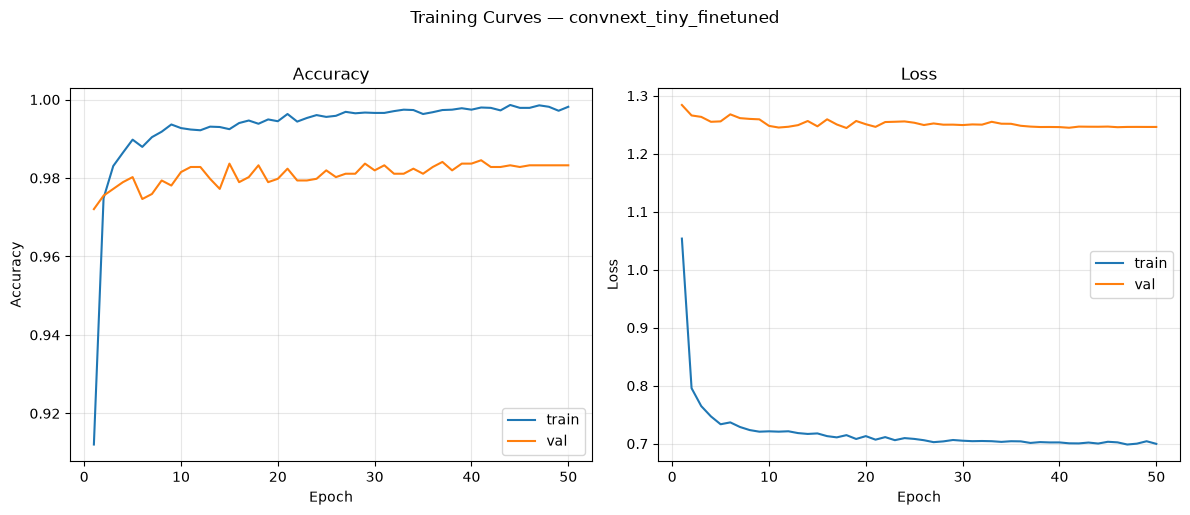

Plot tersimpan di: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\figures\training\convnext_tiny_finetuned.png


In [8]:
report_dir = PROJECT_ROOT / "results" / "reports" / "training" / MODEL_NAME
history_path = report_dir / "history.csv"

if history_path.exists():
    df = pd.read_csv(history_path)

    required_cols = {"epoch", "train_acc", "val_acc", "train_loss", "val_loss"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Kolom history.csv tidak lengkap. Ditemukan: {list(df.columns)}")

    plt.figure(figsize=(12, 5))
    plt.suptitle(f"Training Curves — {MODEL_NAME}", y=1.02)

    plt.subplot(1, 2, 1)
    plt.plot(df["epoch"], df["train_acc"], label="train")
    plt.plot(df["epoch"], df["val_acc"], label="val")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(df["epoch"], df["train_loss"], label="train")
    plt.plot(df["epoch"], df["val_loss"], label="val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    save_dir = PROJECT_ROOT / "results" / "figures" / "training"
    save_dir.mkdir(parents=True, exist_ok=True)

    out_path = save_dir / f"{MODEL_NAME}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Plot tersimpan di: {out_path}")
else:
    print(f"history.csv not found di: {history_path}")